In [ ]:
"""Utilities for preparing financial time series data for Transformer training."""
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple
import yfinance as yf
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import torch.nn as nn
import math


In [ ]:
class StockSequenceDataset(Dataset):
    """Dataset of windowed features and multi-step targets."""

    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


def create_sequences(
    X: np.ndarray,
    y: np.ndarray,
    lookback: int,
    horizon: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Convert flat arrays into sliding windows."""
    X_seq, y_seq = [], []

    for end_idx in range(lookback, len(X) - horizon + 1):
        start_idx = end_idx - lookback
        X_seq.append(X[start_idx:end_idx])
        y_seq.append(y[end_idx:end_idx + horizon].reshape(-1))

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)


def prepare_datasets(
    df: pd.DataFrame,
    feature_columns: List[str] = None,
    target_column: str = "close",
    lookback: int = 20,
    horizon: int = 5,
    batch_size: int = 64
) -> Dict[str, object]:
    """Split data, scale features/target, create windowed DataLoaders."""
    feature_columns = feature_columns or ["open", "high", "low", "close", "volume"]

    df = df.dropna().copy()

    n = len(df)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end - lookback:val_end].copy()
    test_df = df.iloc[val_end - lookback:].copy()

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    feature_scaler.fit(train_df[feature_columns])
    target_scaler.fit(train_df[[target_column]])

    def transform(df_part: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        X = feature_scaler.transform(df_part[feature_columns])
        y = target_scaler.transform(df_part[[target_column]])
        return create_sequences(X, y, lookback, horizon)

    train_X, train_y = transform(train_df)
    val_X, val_y = transform(val_df)
    test_X, test_y = transform(test_df)

    dataloaders = {
        "train": DataLoader(StockSequenceDataset(train_X, train_y), batch_size=batch_size, shuffle=False),
        "val": DataLoader(StockSequenceDataset(val_X, val_y), batch_size=batch_size, shuffle=False),
        "test": DataLoader(StockSequenceDataset(test_X, test_y), batch_size=batch_size, shuffle=False),
    }

    return {
        "dataloaders": dataloaders,
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
    }

In [ ]:
'''
class StockSequenceDataset(Dataset):
    """PyTorch dataset to hold windowed features (X) and targets (y)."""
    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]

def create_sequences(df: pd.DataFrame, feature_cols: List[str], target_col: str, lookback: int, horizon: int = 5):
    """Converts a flat DataFrame into a set of sliding window sequences."""
    X, y = [], []
    features = df[feature_cols].values
    target = df[target_col].values
    for i in range(lookback, len(df) - horizon + 1):
        X.append(features[i-lookback:i])
        y.append(target[i:i+horizon])
    return np.array(X), np.array(y)

def prepare_datasets(df: pd.DataFrame, feature_columns: List[str] = None, target_column: str = "close", lookback: int = 50, batch_size: int = 64) -> Dict[str, object]:
    """Pipeline: 1. Split 2. Scale 3. Create DataLoaders."""
    feature_columns = feature_columns or ["open", "high", "low", "close", "volume"]

    df = df.copy().dropna()

    n = len(df)
    train_df = df.iloc[:int(n * 0.7)].copy()
    val_df = df.iloc[int(n * 0.7):int(n * 0.85)].copy()
    test_df = df.iloc[int(n * 0.85):].copy()

    f_scaler = StandardScaler().fit(train_df[feature_columns])
    t_scaler = StandardScaler().fit(train_df[[target_column]])

    def transform_and_window(data_df):
        data_df = data_df.copy()
        data_df[feature_columns] = f_scaler.transform(data_df[feature_columns])
        return create_sequences(data_df, feature_columns, target_column, lookback, horizon = 5)

    train_X, train_y = transform_and_window(train_df)
    val_X, val_y = transform_and_window(val_df)
    test_X, test_y = transform_and_window(test_df)

    loaders = {
        "train": DataLoader(StockSequenceDataset(train_X, train_y), batch_size=batch_size, shuffle=True),
        "val": DataLoader(StockSequenceDataset(val_X, val_y), batch_size=batch_size),
        "test": DataLoader(StockSequenceDataset(test_X, test_y), batch_size=batch_size)
    }
    return {"dataloaders": loaders, "target_scaler": t_scaler, "train_df": train_df, "val_df": val_df, "test_df": test_df}
'''

'\nclass StockSequenceDataset(Dataset):\n    """PyTorch dataset to hold windowed features (X) and targets (y)."""\n    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:\n        self.X = torch.tensor(X, dtype=torch.float32)\n        self.y = torch.tensor(y, dtype=torch.float32)\n\n    def __len__(self) -> int:\n        return len(self.X)\n\n    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:\n        return self.X[idx], self.y[idx]\n\ndef create_sequences(df: pd.DataFrame, feature_cols: List[str], target_col: str, lookback: int, horizon: int = 5):\n    """Converts a flat DataFrame into a set of sliding window sequences."""\n    X, y = [], []\n    features = df[feature_cols].values\n    target = df[target_col].values\n    for i in range(lookback, len(df) - horizon + 1):\n        X.append(features[i-lookback:i])\n        y.append(target[i:i+horizon])\n    return np.array(X), np.array(y)\n\ndef prepare_datasets(df: pd.DataFrame, feature_columns: List[str] = N

In [ ]:
def download_stock_data(
    ticker: str = "AAPL",
    period: str = "3y",
    interval: str = "1d",
) -> pd.DataFrame:
    """
    Download OHLCV data with yfinance and reshape it for the training pipeline.

    Returned columns:
    open, high, low, close, volume
    """

    data = yf.download(ticker, period=period, interval=interval, auto_adjust=True, progress=False)
    if data.empty:
        raise ValueError(f"No data returned for ticker={ticker}, period={period}, interval={interval}.")

    # yfinance may return a MultiIndex for columns depending on version and parameters.
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.rename(
        columns={
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Volume": "volume",
        }
    )

    cleaned = data[DEFAULT_FEATURE_COLUMNS].copy()
    cleaned = cleaned.dropna().reset_index(drop=True)

    if len(cleaned) <= 20:
        raise ValueError("Downloaded dataset is too small for lookback-based training.")

    return cleaned

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1)]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim: int, d_model: int = 64, nhead: int = 4, num_layers: int = 3, dropout: float = 0.2, horizon: int = 5, dim_feedforward: int = 256):
        super().__init__()
        self.model_type = 'Transformer'
        self.pos_encoder = PositionalEncoding(d_model)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True, dim_feedforward=dim_feedforward)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.input_linear = nn.Linear(input_dim, d_model)
        self.decoder = nn.Linear(d_model, horizon)
        self.d_model = d_model
        self.horizon = horizon

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        src = self.input_linear(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output[:, -1, :])
        return output

In [ ]:
DEFAULT_FEATURE_COLUMNS = ["open", "high", "low", "close", "volume"]
df = download_stock_data(ticker="TSLA", period="5y", interval="1d")

prepared = prepare_datasets(df, feature_columns=DEFAULT_FEATURE_COLUMNS, batch_size = 32)

# Verification Checks
# print("--- Dataframe Overview ---")
# print(f"Total rows: {len(df)}")
# print(f"Columns: {df.columns.tolist()}")
# print("\n--- Split Dimensions ---")
# print(f"Train size: {len(prepared['train_df'])}")
# print(f"Val size:   {len(prepared['val_df'])}")
# print(f"Test size:  {len(prepared['test_df'])}")

# print("\n--- DataLoader Check ---")
# train_loader = prepared['dataloaders']['train']
# for batch_X, batch_y in train_loader:
#     print(f"Batch X shape: {batch_X.shape} (Batch, Lookback, Features)")
#     print(f"Batch y shape: {batch_y.shape} (Batch, Target)")
#     break

# print("\n--- Raw Sample (df head) ---")
# print(df.head())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Ensure model and data are initialized
model = TimeSeriesTransformer(input_dim=5, horizon=5).to(device)
print(model)
# print(f'Model initialized with d_model={model.d_model}')
train_loader = prepared['dataloaders']['train']
val_loader = prepared['dataloaders']['val']

print("Number of samples:", len(train_loader.dataset))
print("Number of batches:", len(train_loader))

Using device: cpu
TimeSeriesTransformer(
  (pos_encoder): PositionalEncoding()
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    )
    (linear1): Linear(in_features=64, out_features=256, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (linear2): Linear(in_features=256, out_features=64, bias=True)
    (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.2, inplace=False)
    (dropout2): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)


In [ ]:
# --- Configuration ---
num_epochs = 150
learning_rate = 0.0001

criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Print sample data from loaders
# print("\n--- Sample Data from Loaders ---")

# print(f"Train Loader - Sample X (first element of first batch):\n{batch_X[0]}\n")
# print(f"Train Loader - Sample y (first element of first batch):\n{batch_y[0]}\n")

# print(f"Training started on {device}...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)

        if batch_idx == 0:
            sample_train_preds = outputs[0].detach().cpu()
            sample_train_true = batch_y[0].detach().cpu()

    # print("Predicted:", sample_train_preds)
    # print("True:", sample_train_true)
    # print("")
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_idx, (batch_X, batch_y) in enumerate(val_loader):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)

            # save the first validation batch for printing
            if batch_idx == 0:
                sample_val_preds = outputs[0].detach().cpu()
                sample_val_true = batch_y[0].detach().cpu()

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")


    # if (epoch + 1) % 50 == 0:
    #     print("Predicted validation labels:")
    #     print(sample_val_preds)
    #     print("True validation labels:")
    #     print(sample_val_true)
    #     print("-" * 50)

print("Training complete!")

Epoch [10/150] | Train Loss: 0.043046 | Val Loss: 0.173937
Epoch [20/150] | Train Loss: 0.036513 | Val Loss: 0.175462
Epoch [30/150] | Train Loss: 0.035032 | Val Loss: 0.172841
Epoch [40/150] | Train Loss: 0.033282 | Val Loss: 0.172625
Epoch [50/150] | Train Loss: 0.033953 | Val Loss: 0.170535
Epoch [60/150] | Train Loss: 0.033620 | Val Loss: 0.170189
Epoch [70/150] | Train Loss: 0.033452 | Val Loss: 0.170326
Epoch [80/150] | Train Loss: 0.034061 | Val Loss: 0.170310
Epoch [90/150] | Train Loss: 0.032930 | Val Loss: 0.170315
Epoch [100/150] | Train Loss: 0.033857 | Val Loss: 0.170294
Epoch [110/150] | Train Loss: 0.034796 | Val Loss: 0.170287
Epoch [120/150] | Train Loss: 0.033864 | Val Loss: 0.170286
Epoch [130/150] | Train Loss: 0.034446 | Val Loss: 0.170284
Epoch [140/150] | Train Loss: 0.032484 | Val Loss: 0.170281
Epoch [150/150] | Train Loss: 0.032872 | Val Loss: 0.170279
Training complete!


# Predicting horizon = 5 days

Predicted_scaled: [2.0041366 2.053017  2.0948837 2.1305974 2.0564795]
Actual_scaled: [1.4832263 1.6664261 1.6456729 1.7104368 1.7184879]
Predicted_inverse_scaled: [348.5264  351.25858 353.59872 355.59494 351.45212]
Actual_inverse_scaled: [319.41 329.65 328.49 332.11 332.56]


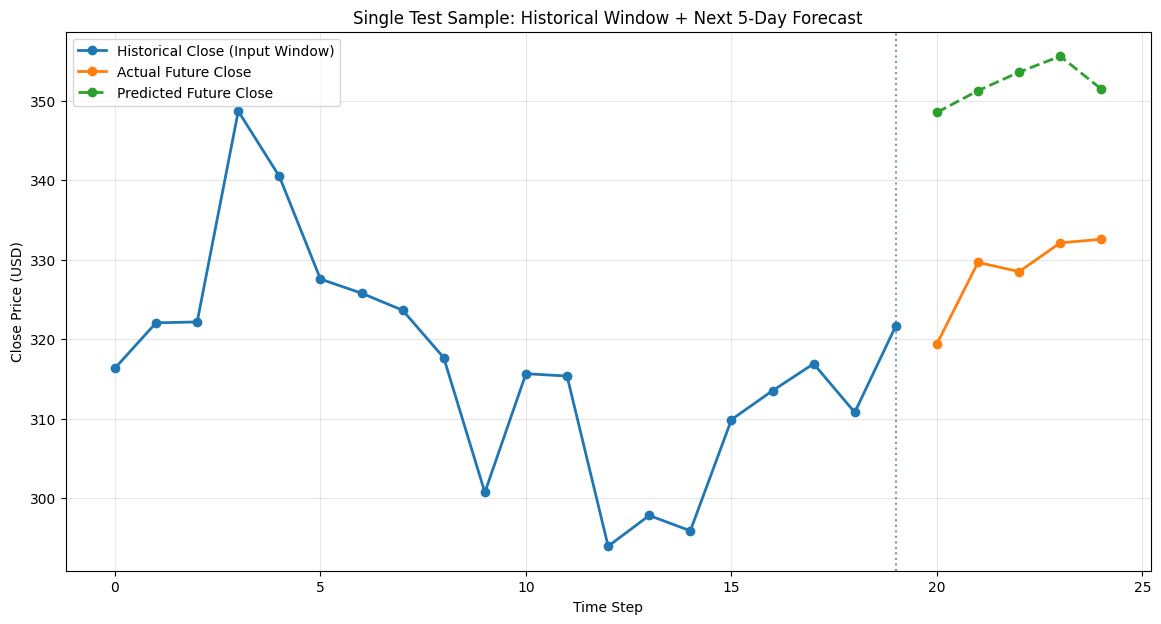

Historical window: [316.3500061  322.04998779 322.16000366 348.67999268 340.47000122
 327.54998779 325.77999878 323.63000488 317.66000366 300.70999146
 315.6499939  315.3500061  293.94000244 297.80999756 295.88000488
 309.86999512 313.51000977 316.8999939  310.77999878 321.67001343]
Actual next 5 closes: [319.41000366 329.6499939  328.48999023 332.10998535 332.55999756]
Predicted next 5 closes: [348.5264  351.25858 353.59872 355.59494 351.45212]


In [ ]:
model.eval()
target_scaler = prepared["target_scaler"]
test_dataset = prepared["dataloaders"]["test"].dataset
test_df = prepared["test_df"]

lookback = 20
horizon = 5
sample_idx = 5  # choose which test sample you want

# Get one sample from the test dataset
single_X, single_y = test_dataset[sample_idx]
single_X = single_X.unsqueeze(0).to(device)

with torch.no_grad():
    pred_scaled = model(single_X).cpu().numpy().flatten()   # shape: [5]
actual_scaled = single_y.numpy().flatten()   # shape: [5]
print(f"Predicted_scaled: {pred_scaled}")
print(f"Actual_scaled: {actual_scaled}")
# Inverse transform future closes
pred_prices = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_future_prices = target_scaler.inverse_transform(actual_scaled.reshape(-1, 1)).flatten()
print(f"Predicted_inverse_scaled: {pred_prices}")
print(f"Actual_inverse_scaled: {actual_future_prices}")
# Get the historical window of ACTUAL closes before the prediction
# sample_idx in test_dataset corresponds to a window ending right before forecast starts
test_close_series = test_df["close"].values

window_start = sample_idx
window_end = sample_idx + lookback
future_end = window_end + horizon

history_prices = test_close_series[window_start:window_end]
actual_future_from_df = test_close_series[window_end:future_end]

# x-axis positions
history_x = np.arange(len(history_prices))
future_x = np.arange(len(history_prices), len(history_prices) + horizon)

plt.figure(figsize=(14, 7))

# Historical window
plt.plot(history_x, history_prices, marker="o", label="Historical Close (Input Window)", linewidth=2)

# Actual future
plt.plot(future_x, actual_future_from_df, marker="o", linewidth=2, label="Actual Future Close")

# Predicted future
plt.plot(future_x, pred_prices, marker="o", linestyle="--", linewidth=2, label="Predicted Future Close")

# Divider between history and forecast
plt.axvline(x=len(history_prices) - 1, linestyle=":", alpha=0.7)

plt.title("Single Test Sample: Historical Window + Next 5-Day Forecast")
plt.xlabel("Time Step")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Historical window:", history_prices)
print("Actual next 5 closes:", actual_future_from_df)
print("Predicted next 5 closes:", pred_prices)

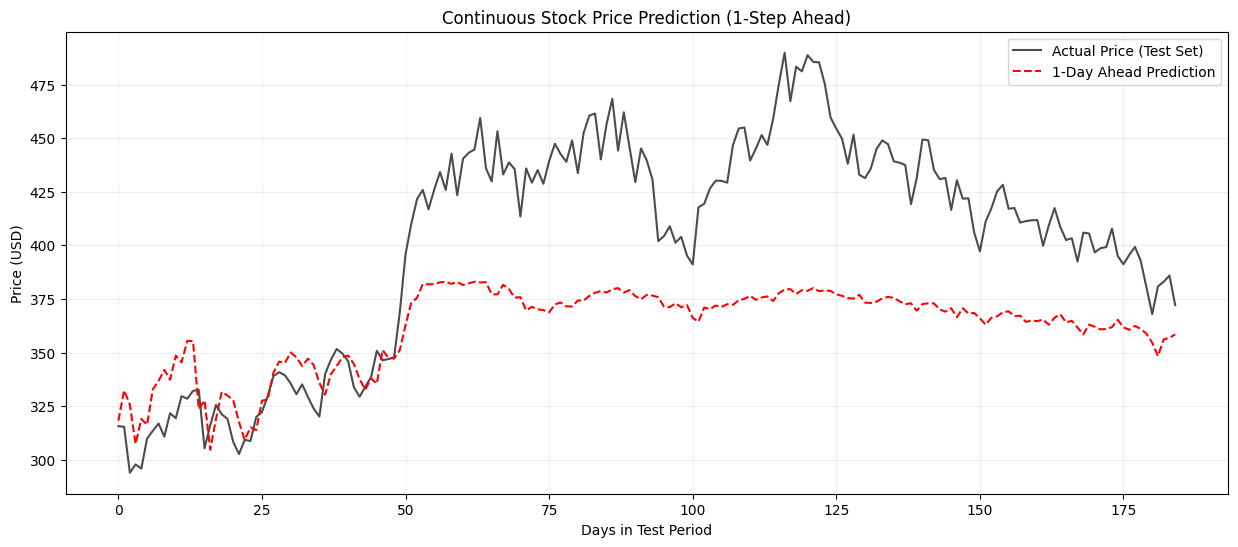

Note: This plot shows only the first day of each forecast window to provide a continuous timeline.


In [ ]:
# To make a 'normal' looking plot, we only take the first prediction from each window
# This removes the overlapping 'weirdness'

# all_preds shape is (N, horizon), all_actuals is (N, horizon)
# We take index [:, 0] to get the 1-step ahead prediction for every window
first_step_preds = all_preds[:, 0].reshape(-1, 1)
first_step_actuals = all_actuals[:, 0].reshape(-1, 1)

# Inverse scale
clean_preds = target_scaler.inverse_transform(first_step_preds).flatten()
clean_actuals = target_scaler.inverse_transform(first_step_actuals).flatten()

plt.figure(figsize=(15, 6))
plt.plot(clean_actuals, label='Actual Price (Test Set)', color='black', alpha=0.7)
plt.plot(clean_preds, label='1-Day Ahead Prediction', color='red', linestyle='--')

plt.title('Continuous Stock Price Prediction (1-Step Ahead)')
plt.xlabel('Days in Test Period')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("Note: This plot shows only the first day of each forecast window to provide a continuous timeline.")